In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000, n_features=20, centers=3)

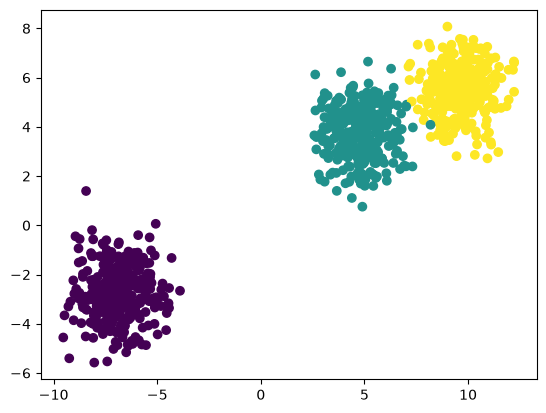

In [4]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.33, random_state=42)

In [8]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [9]:
x_train

array([[  5.30685566,   2.0727011 ,   4.27791954, ...,  -1.6291306 ,
         -2.81055923, -10.15638188],
       [ -8.10934048,  -1.25427246,   0.7110294 , ...,   3.77094367,
         -7.50009687,   8.75335321],
       [  4.32867503,   2.94063219,   3.83159359, ...,  -1.34830567,
         -1.91793894, -10.46836472],
       ...,
       [  3.63195829,   5.05153044,   3.56450966, ...,  -0.07855765,
         -3.35458322,  -9.96943849],
       [  3.88715782,   3.14998796,   2.15840217, ...,  -2.14912465,
         -1.85830452,  -9.72047322],
       [ -6.86143883,  -2.38060297,  -0.59695344, ...,   3.22357514,
         -9.06363346,   7.80178694]], shape=(670, 20))

In [13]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

In [15]:
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [16]:
x_train_pca

array([[-4.04101163,  1.44892942],
       [ 3.71870607,  2.09217991],
       [-4.12805529,  1.53187197],
       ...,
       [-4.23560689,  1.05431749],
       [-5.07392189,  1.0991411 ],
       [ 4.15914574,  1.4421544 ]], shape=(670, 2))

In [20]:
from sklearn.cluster import KMeans

In [25]:
wcss=[]
for k in range(1,11):
    kmean=KMeans(n_clusters=k,
                 init='k-means++')
    kmean.fit(x_train_pca)
    wcss.append(kmean.inertia_)

In [26]:
wcss

[12387.673164776534,
 5444.351888108648,
 111.75434771753203,
 97.73620598711678,
 82.16502207394308,
 75.94891258643467,
 62.77686340153065,
 56.082491443766614,
 48.28691980774079,
 49.463942806675746]

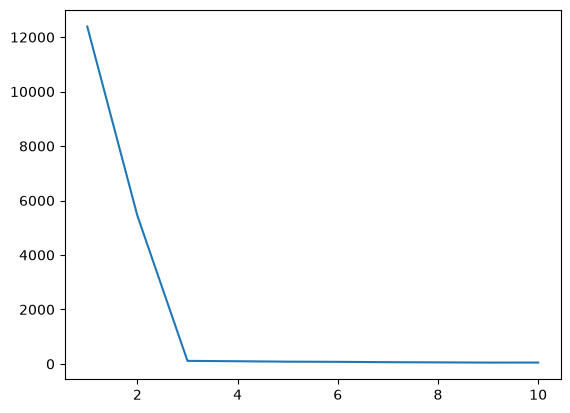

In [27]:
plt.plot(range(1,11), wcss)
plt.show()

In [28]:
kmeans=KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(x_train_pca)
y_pred=kmeans.predict(x_test_pca)

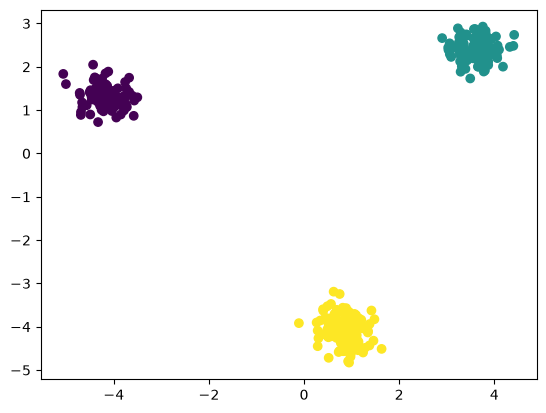

In [31]:
plt.scatter(x_test_pca[:,0], x_test_pca[:,1], c=y_pred)

In [36]:
from kneed import KneeLocator

In [39]:
kl=KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(kl.elbow)

3
